

**Part 2. Lifetime exposure**
- GMT mapping 
- lifetime exposure functions

To do ! 

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

sys.path.append('..')
from gmt_mapping import * 

## 1) Load_GMT()

In [32]:
dir_temperature_trajectories

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/temperature-trajectories'

In [60]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrmean',
)


In [34]:
df_GMT_strj


,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,...,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417
1951,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,...,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391
1952,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,...,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499
1953,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,...,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225
1954,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,...,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2116,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2117,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2118,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329


In [5]:
df_GMT_OS.tail(20)

,1.4
2100,1.424
2101,1.414
2102,1.404
2103,1.404
2104,1.404
2105,1.439
2106,1.439
2107,1.439
2108,1.439
2109,1.439


In [7]:
df_GMT_noOS.tail(20)

,1.3
2100,1.344
2101,1.354
2102,1.354
2103,1.354
2104,1.354
2105,1.352
2106,1.352
2107,1.352
2108,1.352
2109,1.352


In [9]:
df_GMT_15.tail(20)


,1.3
2100,1.336467
2101,1.361027
2102,1.361027
2103,1.361027
2104,1.361027
2105,1.361027
2106,1.361027
2107,1.361027
2108,1.361027
2109,1.361027


In [11]:
df_GMT_20.tail(20)

,2.0
2100,1.978587
2101,1.980163
2102,1.980163
2103,1.980163
2104,1.980163
2105,1.980163
2106,1.980163
2107,1.980163
2108,1.980163
2109,1.980163


In [35]:
ds_GMT_STS

<xarray.Dataset>
Dimensions:     (time: 451, percentile: 4, scenario: 4)
Coordinates:
  * time        (time) int64 1850 1851 1852 1853 1854 ... 2297 2298 2299 2300
  * percentile  (percentile) object '50.0' '95.0' '98.0' '99.0'
  * scenario    (scenario) object 'ModAct' 'Ren' 'LD' 'SP'
Data variables:
    tas         (time, percentile, scenario) float64 ...
Attributes:
    Description:  Trajectories of Global Surface Air Temperature for the Stre...
    Model:        FaIRv1.6.4
    Method:       These scenarios were originally designed for the project PR...
    region:       World
    contact:      Yann Quilcaille <yann.quilcaille@env.ethz.ch>

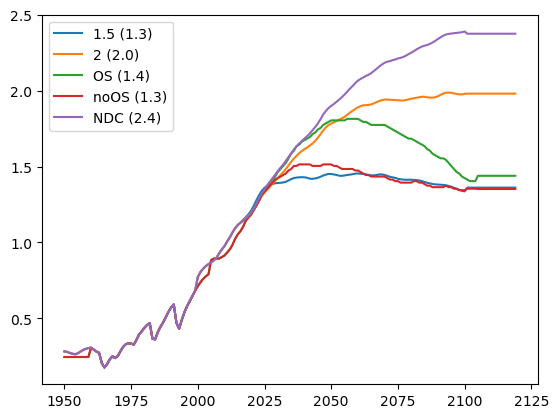

In [12]:
fig, ax = plt.subplots()
labels=['1.5','2','OS', 'noOS', 'NDC']

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): #
    df.plot(ax=ax)
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'

ax.legend(labels, loc='upper left')


# issues: 
# 3) other extension methods dont work properly I think.. 

# questions
# how is NDC chosen/set
# how different are the 1.5/2 deg scenariosa nd the strj and how are they made/selected
# how were OS and noOS selected


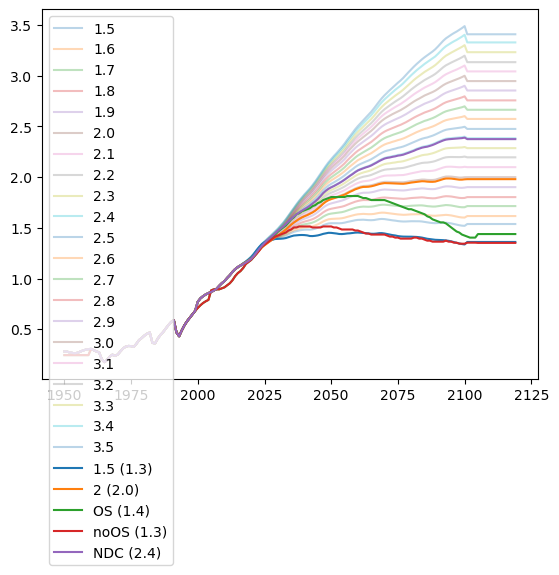

In [ ]:
fig, ax = plt.subplots()

df_GMT_strj.plot(ax=ax, alpha=.3)

labels=['1.5','2','OS', 'noOS', 'NDC']

ax.set_prop_cycle(None) 

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): 
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')


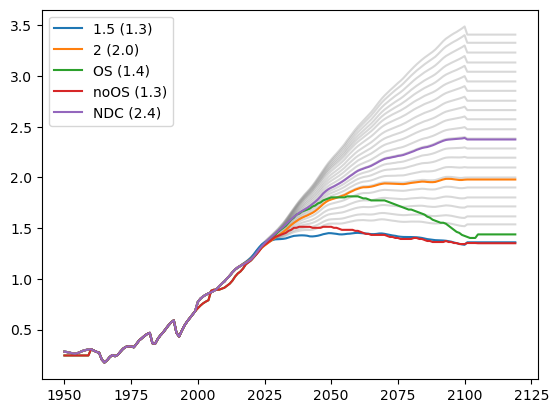

In [61]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

In [50]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
)

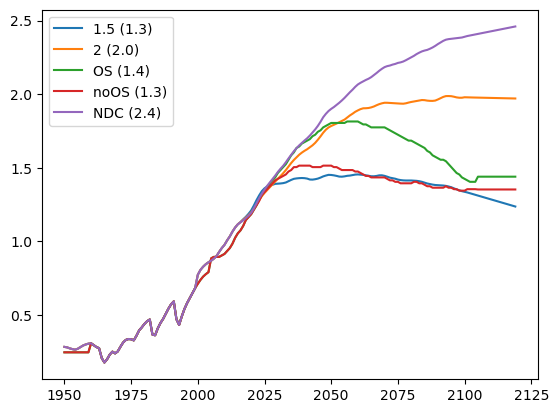

In [51]:
fig, ax = plt.subplots()
labels=['1.5','2','OS', 'noOS', 'NDC']

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): #
    df.plot(ax=ax)
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'

ax.legend(labels, loc='upper left')

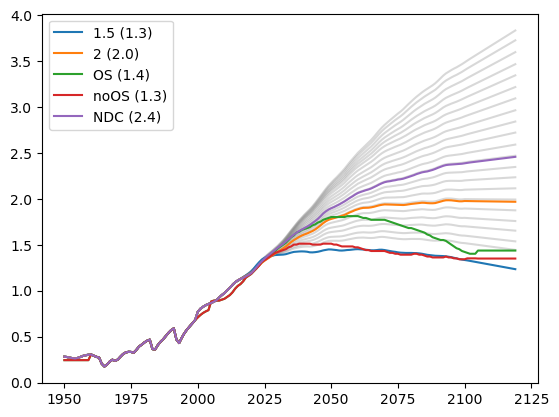

In [59]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

In [3]:
## test different extensions

In [4]:

def extend_gmt_to_year_range(df, year_start=1950, year_end=2119, gmt_extend_method=None):
    """
    Extend a GMT time series (Series or DataFrame) to a given year range.
    
    Handles both backward and forward extension using specified method.
    
    Parameters
    ----------
    df : pd.Series or pd.DataFrame
        Input data indexed by year.
    year_start : int, optional
        Earliest year to extend to (fills backward if needed).
    year_end : int, optional
        Latest year to extend to (fills forward if needed).
    gmt_extend_method : {'10yrmean', 'lastyear', '10yrtrend'}, optional
        Method for forward extension beyond the last available year.
    
    Returns
    -------
    pd.DataFrame
        Extended dataset over [year_start, year_end].
    """
    # --- Ensure DataFrame ---
    if isinstance(df, pd.Series):
        df = df.to_frame()
        df.columns = [f"{df.loc[2100].values[0]:.1f}"] if 2100 in df.index else ["value"] # [str(round(df.loc[2100].values[0], 2))] if 2100 in df.index else ["value"]

    df = df.copy()
    df.index = df.index.astype(int)
    
    min_year, max_year = int(np.nanmin(df.index)), int(np.nanmax(df.index))

    # --- Backward extension ---
    if year_start is not None and min_year > year_start:
        first_10y_mean = df.iloc[:10, :].mean()
        for year in range(year_start, min_year):
            df.loc[year] = first_10y_mean
    
    df = df.sort_index()

    # --- Forward extension ---
    if year_end is not None and max_year < year_end:
        if gmt_extend_method == "10yrmean":
            last_10y_mean = df.iloc[-10:, :].mean()
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = last_10y_mean

        elif gmt_extend_method == "lastyear":
            last_year_vals = df.iloc[-1, :]
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = last_year_vals

        elif gmt_extend_method == "10yrtrend":
            yrs = np.arange(max_year - 9, max_year + 1)
            trends = {col: np.polyfit(yrs, df.loc[yrs, col].astype(float), 1) for col in df.columns}
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = {col: np.polyval(trends[col], year) for col in df.columns}

    # --- Sort index and restrict range ---
    df = df.sort_index()
    if year_start is not None or year_end is not None:
        df = df.loc[
            (df.index >= (year_start if year_start is not None else df.index.min())) &
            (df.index <= (year_end if year_end is not None else df.index.max()))
        ]

    return df

In [14]:
from scipy.io import loadmat

# Load GMT_OS
mat_data = loadmat(dir_temperature_trajectories + '/temperature-trajectories_Wim/GMT_OS.mat', squeeze_me=True)
GMT_OS = mat_data['GMT_OS'].flatten()
years = np.arange(1960, 1960 + len(GMT_OS))
df_GMT_OS = pd.Series(GMT_OS, index=years)
df_GMT_OS.name = None
df_GMT_OS.index.name = None

# Load GMT_noOS
mat_data = loadmat(dir_temperature_trajectories + '/temperature-trajectories_Wim/GMT_noOS.mat', squeeze_me=True)
GMT_noOS = mat_data['GMT_noOS'].flatten()
years = np.arange(1960, 1960 + len(GMT_noOS))
df_GMT_noOS = pd.Series(GMT_noOS, index=years)
df_GMT_noOS.name = None
df_GMT_noOS.index.name = None



In [16]:
df_GMT_OS

1960    0.306832
1961    0.293686
1962    0.281428
1963    0.273481
1964    0.206345
          ...   
2109    1.439000
2110    1.439000
2111    1.439000
2112    1.439000
2113    1.439000
Length: 154, dtype: float64

<Axes: >

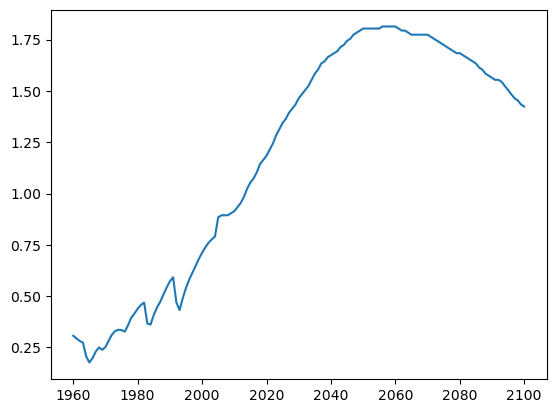

In [ ]:
df_GMT_OS.loc[:2100].plot() # try extending OS with trend - too much no?

In [27]:
df_GMT_OS = extend_gmt_to_year_range(df_GMT_OS.loc[:2100],1950, 2119, gmt_extend_method='lastyear')
df_GMT_noOS = extend_gmt_to_year_range(df_GMT_noOS.loc[:2100],1950,2119, gmt_extend_method='lastyear')

<Axes: >

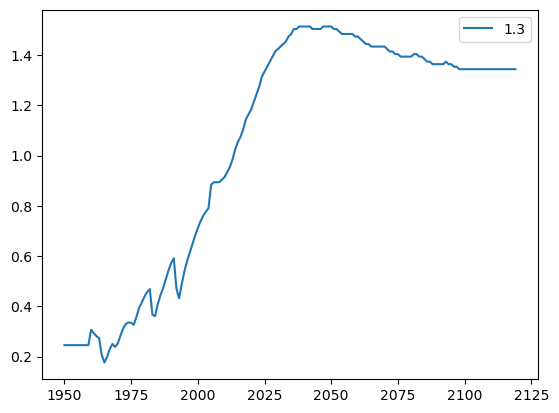

In [28]:
df_GMT_noOS.plot()

<Axes: >

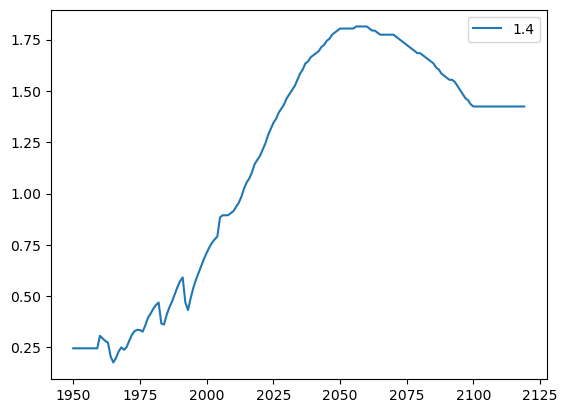

In [29]:
df_GMT_OS.plot()

In [39]:
year_start=1950

# collect new ar6 scens from IASA explorer
df_GMT_ar6 = pd.read_csv(dir_temperature_trajectories+'/temperature-trajectories_AR6/ar6_c1_c7_nogaps_2000-2100.csv',header=0)
df_GMT_ar6.loc[:,'Model'] = df_GMT_ar6.loc[:,'Model']+'_'+df_GMT_ar6.loc[:,'Scenario']
df_GMT_ar6 = df_GMT_ar6.drop(columns=['Scenario','Region','Variable','Unit']).transpose()
df_GMT_ar6.columns=df_GMT_ar6.loc['Model',:]
df_GMT_ar6.columns.name = None
df_GMT_ar6 = df_GMT_ar6.drop(df_GMT_ar6.index[0])
df_GMT_ar6 = df_GMT_ar6.dropna(axis=1)
df_GMT_ar6.index = df_GMT_ar6.index.astype(int)
df_hist_all = df_GMT_15.loc[year_start:1999]
df_hist_all = pd.concat([df_hist_all for i in range(len(df_GMT_ar6.columns))],axis=1)
df_hist_all.columns = df_GMT_ar6.columns
df_GMT_ar6 = pd.concat([df_hist_all,df_GMT_ar6],axis=0) # add historical values to additional scenarios

# drop dups
df_GMT_ar6 = df_GMT_ar6[~df_GMT_ar6.index.duplicated(keep='first')]

# get new trajects - this overwrites the above df_GMT_15
df_GMT_lb, df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_30, df_GMT_40 = ar6_scen_grab(
    scen_thresholds,
    df_GMT_ar6,
)  

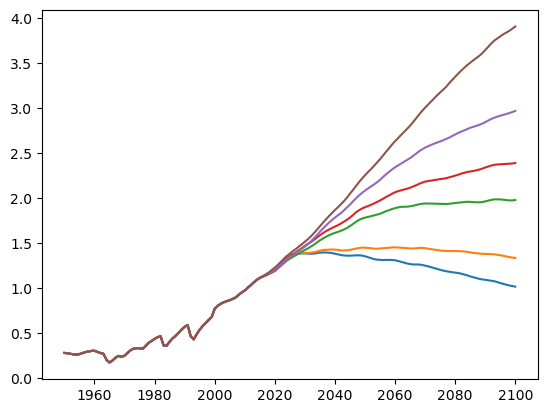

In [ ]:
fig, ax = plt.subplots()

for df in [df_GMT_lb, df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_30, df_GMT_40]:
    df.plot()

# ar6_scen_grab takes lowest highest and some in the middle, then later interpolates between all of these to have regularly spaced at 0.1 deg intervals in 2100

<Axes: >

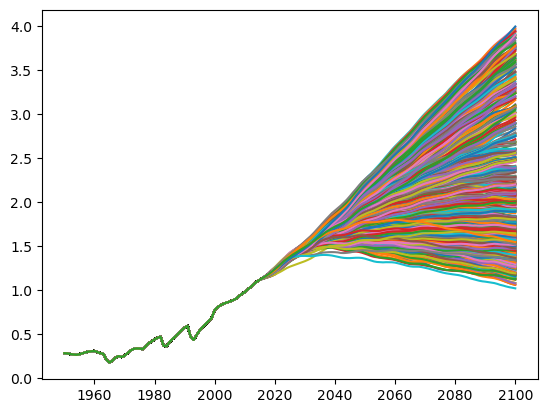

In [ ]:
df_GMT_ar6.plot(legend=False)

# all the input scenarios, with one pathway until 1999 

# 2) Load_ISIMIP

Develop how to load data and GMT-mapping metadata

## 2a. GMT per simulation

In [23]:

GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']

extremes="FWI95d" # e.g. "FWI95d"
model_names = GCMs
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI' # structure should be climatedata_dir/scenario/model
scenarios = scenarios
df_GMT_strj = None # add also others! loop over them ! add labels 

smoothing=True
rolling_window=21

model_gmst_dir = None # need this!! and prep the GMST 

gmt_mapping_method = 'year-to-year' 

In [4]:
extreme = extremes
model=model_names[0]
scenario=scenarios[1]

In [5]:
scenario

'ssp126'

In [6]:
# initialise counter, metadata dictionary, pic list, pic meta, and 
i = 1
d_climate_data_meta = {}

In [10]:
filepath = glob.glob(os.path.join(climatedata_dir, scenario, model, f'*{model}*{extreme}.nc'))[0]
print(f'Loading {filepath}')

# load data: annual count of exceedances of threshold (already preprocessed)
da_rcp = xr.open_dataarray(filepath, chunks='auto')

# save metadata
d_climate_data_meta[i] = {
    'extreme': extreme,
    'model': model,
    'scenario': scenario,
}

#load associated historical variable
filepath = glob.glob(os.path.join(climatedata_dir, 'historical', model, f'*{model}*{extreme}.nc'))[0]
print(f'Loading {filepath}')
da_hist = xr.open_dataarray(filepath, chunks='auto')

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc


In [11]:
da_exceedances = xr.concat([da_hist,da_rcp], dim='time')


In [12]:
da_exceedances

<xarray.DataArray 'FWI95d' (time: 151, latitude: 392, longitude: 500)>
dask.array<concatenate, shape=(151, 392, 500), dtype=int64, chunksize=(85, 392, 500), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float64 -14.96 -14.86 -14.76 ... 34.74 34.84 34.94
  * latitude   (latitude) float64 71.09 70.99 70.89 70.79 ... 32.19 32.09 31.99
    quantile   float64 0.95
  * time       (time) datetime64[ns] 1950-12-31 1951-12-31 ... 2100-12-31

## GMT per simulation

In [39]:
filepath_model_gmst='../data/gmst-models/gmst_models_1850_2100_fwi.csv'
df_GMT = pd.read_csv(filepath_model_gmst,index_col=0)
df_GMT['year'] = df_GMT['year'].astype(int)


In [20]:
df_GMT

,year,experiment_id,source_id,tas
0,1850,historical,ACCESS-CM2,287.007494
1,1850,historical,CNRM-ESM2-1,286.900465
2,1850,historical,CanESM5,286.806542
3,1850,historical,EC-Earth3,287.029662
4,1850,historical,MPI-ESM1-2-HR,287.064616
...,...,...,...,...
7525,2100,ssp585,CNRM-ESM2-1,292.475368
7526,2100,ssp585,CanESM5,294.452385
7527,2100,ssp585,EC-Earth3,293.272894
7528,2100,ssp585,MPI-ESM1-2-HR,291.375668


In [26]:
df_wide = df_GMT.pivot_table(
    index=["year", "experiment_id"],
    columns="source_id",
    values="tas"
)
df_wide

source_id           ACCESS-CM2  CNRM-ESM2-1     CanESM5   EC-Earth3  \
year experiment_id                                                    
1850 historical     287.007494   286.900465  286.806542  287.029662   
1851 historical     287.016985   287.081066  286.551052  287.130825   
1852 historical     287.174542   287.005218  286.622251  287.183553   
1853 historical     287.070948   286.872643  286.776655  287.000297   
1854 historical     287.141159   286.873972  286.638360  286.945980   
...                        ...          ...         ...         ...   
2099 ssp585         293.114663   292.592435  294.441621  293.299713   
2100 ssp126         289.419884   288.991151  289.683514  289.268752   
     ssp245         290.470334   290.101415  291.057557  290.430415   
     ssp370         291.928374   291.379378  293.137034  291.863306   
     ssp585         293.145303   292.475368  294.452385  293.272894   

source_id           MPI-ESM1-2-HR  MRI-ESM2-0  
year experiment_id                             
1850 historical        287.064616  286.939424  
1851 historical        287.088070  286.991131  
1852 historical        287.281398  286.910700  
1853 historical        287.388171  286.805766  
1854 historical        287.093118  286.766465  
...                           ...         ...  
2099 ssp585            291.458242  291.567732  
2100 ssp126            288.668542  288.494456  
     ssp245            289.534073  289.579336  
     ssp370            290.874307  290.906602  
     ssp585            291.375668  291.848270  

[509 rows x 6 columns]

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

filepath_model_gmst='../data/gmst-models/gmst_models_1850_2100_fwi.csv'
df_GMT = pd.read_csv(filepath_model_gmst,index_col=0)
df_GMT['year'] = df_GMT['year'].astype(int)

# --- 1. Compute baseline (1850–1900 mean for each model) ---
baseline = (
    df_GMT.query("1850 <= year <= 1900")
    .groupby("source_id")["tas"]
    .mean()
    .rename("tas_baseline")
)
df_GMT = df_GMT.merge(baseline, on="source_id")
df_GMT["tas_anom"] = df_GMT["tas"] - df_GMT["tas_baseline"]

# --- 2. Pivot to wide format ---
df_wide = df_GMT.pivot_table(
    index=["year", "experiment_id"],
    columns="source_id",
    values="tas_anom"
)


In [ ]:
baseline - 273.15 # avg T in 1850-1900


source_id
ACCESS-CM2       13.754873
CNRM-ESM2-1      13.658067
CanESM5          13.563354
EC-Earth3        13.962913
MPI-ESM1-2-HR    13.924616
MRI-ESM2-0       13.731488
Name: tas_baseline, dtype: float64

In [6]:
df_wide

source_id           ACCESS-CM2  CNRM-ESM2-1   CanESM5  EC-Earth3  \
year experiment_id                                                 
1850 historical       0.102621     0.092399  0.093188  -0.083251   
1851 historical       0.112112     0.272999 -0.162302   0.017912   
1852 historical       0.269669     0.197152 -0.091103   0.070640   
1853 historical       0.166075     0.064576  0.063301  -0.112616   
1854 historical       0.236286     0.065905 -0.074994  -0.166933   
...                        ...          ...       ...        ...   
2099 ssp585           6.209790     5.784368  7.728267   6.186800   
2100 ssp126           2.515011     2.183085  2.970160   2.155840   
     ssp245           3.565461     3.293349  4.344203   3.317502   
     ssp370           5.023501     4.571312  6.423680   4.750394   
     ssp585           6.240430     5.667301  7.739031   6.159981   

source_id           MPI-ESM1-2-HR  MRI-ESM2-0  
year experiment_id                             
1850 historical         -0.010000    0.057936  
1851 historical          0.013454    0.109643  
1852 historical          0.206782    0.029212  
1853 historical          0.313555   -0.075722  
1854 historical          0.018502   -0.115023  
...                           ...         ...  
2099 ssp585              4.383627    4.686244  
2100 ssp126              1.593926    1.612968  
     ssp245              2.459458    2.697849  
     ssp370              3.799691    4.025114  
     ssp585              4.301053    4.966782  

[509 rows x 6 columns]

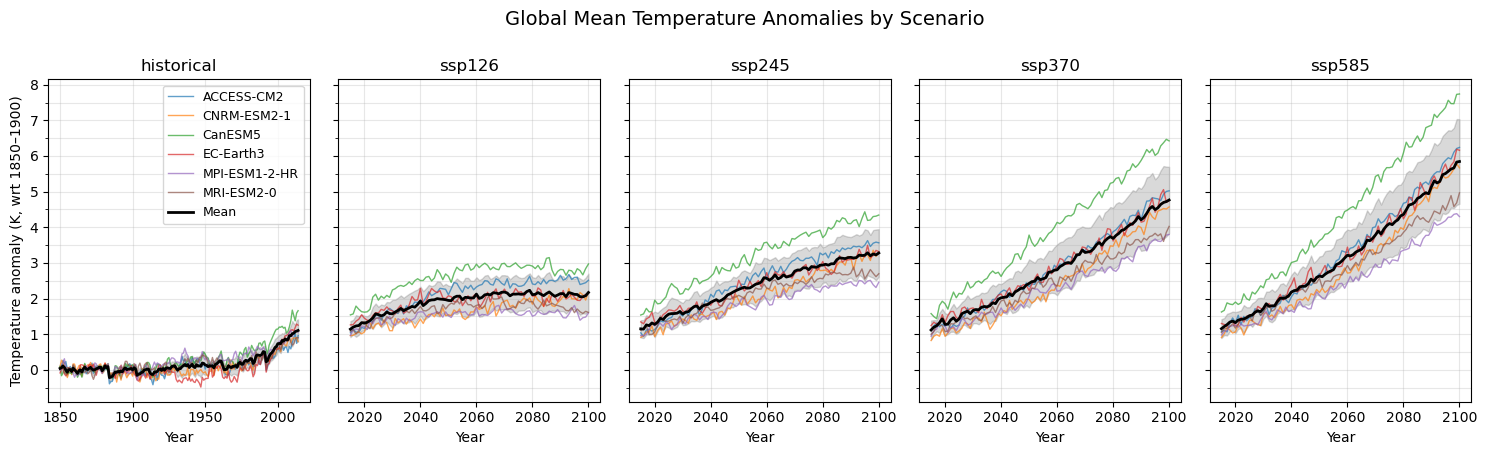

In [21]:

# --- 3. Plot setup ---
scenarios = df_wide.index.get_level_values("experiment_id").unique()
n_scenarios = len(scenarios)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_scenarios,
    figsize=(3 * n_scenarios, 4.5),
    sharey=True
)

if n_scenarios == 1:
    axes = [axes]

# --- 4. Plot each scenario ---
for ax, scenario in zip(axes, scenarios):
    df_scenario = df_wide.xs(scenario, level="experiment_id")

    # Plot individual model lines
    for model in df_scenario.columns:
        ax.plot(df_scenario.index, df_scenario[model], lw=1, alpha=0.7, label=model)

    # Ensemble mean and ±1σ
    mean = df_scenario.mean(axis=1)
    std = df_scenario.std(axis=1)
    ax.plot(df_scenario.index, mean, color="black", lw=2, label="Mean")
    ax.fill_between(df_scenario.index, mean - std, mean + std, color="black", alpha=0.15)

    ax.set_title(scenario)
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)
    ax.grid(True, which='minor', alpha=0.3)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))

axes[0].set_ylabel("Temperature anomaly (K, wrt 1850–1900)")
axes[0].legend(bbox_to_anchor=(1,1), fontsize=9)
fig.suptitle("Global Mean Temperature Anomalies by Scenario", fontsize=14, y=1)
plt.tight_layout()
plt.show()


In [79]:
gmt_anomaly_baseline_period = (1850,1900)
gmt_anomaly_correction = 0 
modelname=GCMs[0]
scenario=scenarios[2]

# simpler for the code 
df_GMT = pd.read_csv(filepath_model_gmst,index_col=0)
df_GMT['year'] = df_GMT['year'].astype(int)
modelname = model if model != 'EC-EARTH' else 'EC-Earth3'
df_GMT_hist = df_GMT[(df_GMT['experiment_id']=='historical') & (df_GMT['source_id']==modelname)].set_index('year').drop(columns=['experiment_id','source_id']).dropna()
df_GMT_rcp = df_GMT[(df_GMT['experiment_id']==scenario) & (df_GMT['source_id']==modelname)].set_index('year').drop(columns=['experiment_id','source_id']).dropna()

# concatenate historical and future GMT data
df_GMT = pd.concat([df_GMT_hist,df_GMT_rcp])

# convert GMT from absolute values to anomalies - if you use a non 1850-1900 period should provide a gmt_anomaly_correction
df_GMT = df_GMT - df_GMT.loc[gmt_anomaly_baseline_period[0] : gmt_anomaly_baseline_period[1]].mean() + gmt_anomaly_correction



In [80]:
df_GMT

,tas
year,
1850,0.057936
1851,0.109643
1852,0.029212
1853,-0.075722
1854,-0.115023
...,...
2096,2.677123
2097,2.816019
2098,2.710975


### GMT anomaly correction

To make the timeseries relative to 1985-2014 warming level 

In [43]:


filepath_gmt_obs = '../data/gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'

gmt_obs = pd.read_csv(filepath_gmt_obs,skiprows=3,index_col=0, na_values=-999,usecols=[0,1,2,3,4,5])

gmt_obs

,ERA5,JRA-3Q,Berkeley Earth,GISTEMP,HadCRUT5
Year,,,,,
1850,NaN,NaN,-0.084,NaN,-0.084
1851,NaN,NaN,0.014,NaN,0.107
1852,NaN,NaN,0.052,NaN,0.104
1853,NaN,NaN,0.035,NaN,0.071
1854,NaN,NaN,0.016,NaN,0.052
...,...,...,...,...,...
2020,1.310,1.263,1.261,1.274,1.258
2021,1.155,1.082,1.112,1.116,1.099
2022,1.181,1.146,1.148,1.161,1.138


<Axes: xlabel='Year'>

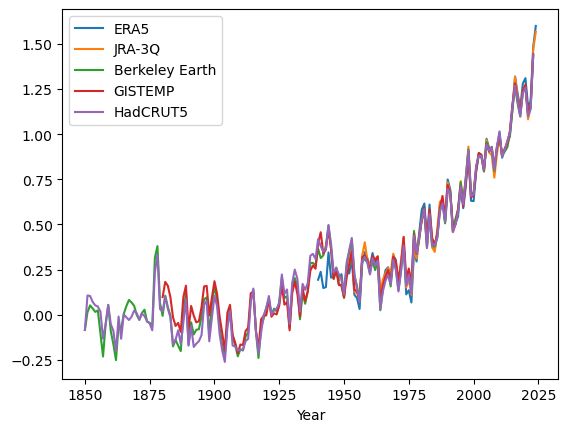

In [44]:
gmt_obs.plot()

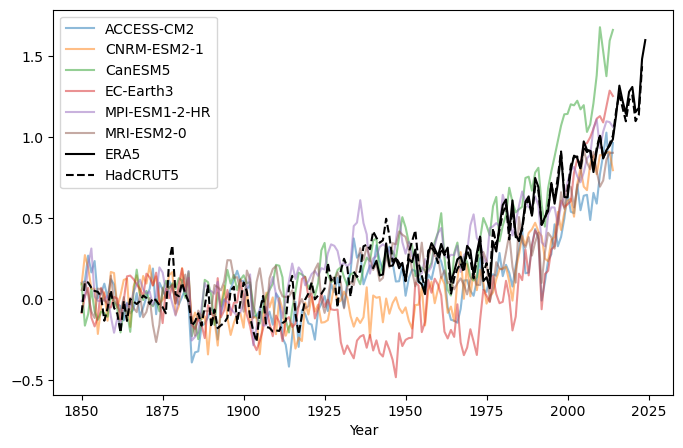

In [65]:
fig,ax = plt.subplots(figsize=(8,5))

df_scenario = df_wide.xs('historical', level="experiment_id")
df_scenario.plot(ax=ax, alpha=.5)

gmt_obs['ERA5'].plot(ax=ax, c='k')
gmt_obs['HadCRUT5'].plot(ax=ax, c='k', ls='--')

plt.legend()

### do it all relative to 1985-2014 !

In [77]:
gmt_obs[['ERA5']].loc[1985:2014].mean()[0]

0.7432

In [71]:
gmt_obs.loc[1985:2014].mean()

ERA5              0.743200
JRA-3Q            0.748733
Berkeley Earth    0.747667
GISTEMP           0.749267
HadCRUT5          0.746967
dtype: float64

In [76]:
gmt_obs.loc[1850:1900].mean()

ERA5                   NaN
JRA-3Q                 NaN
Berkeley Earth   -0.013039
GISTEMP           0.052286
HadCRUT5         -0.020608
dtype: float64

In [84]:
scenarios[2]

'ssp245'

In [82]:
df_scenario = pd.concat([df_wide.xs('historical', level="experiment_id"), df_wide.xs(scenarios[2], level="experiment_id")])
df_scenario

source_id,ACCESS-CM2,CNRM-ESM2-1,CanESM5,EC-Earth3,MPI-ESM1-2-HR,MRI-ESM2-0
year,,,,,,
1850,0.102621,0.092399,0.093188,-0.083251,-0.010000,0.057936
1851,0.112112,0.272999,-0.162302,0.017912,0.013454,0.109643
1852,0.269669,0.197152,-0.091103,0.070640,0.206782,0.029212
1853,0.166075,0.064576,0.063301,-0.112616,0.313555,-0.075722
1854,0.236286,0.065905,-0.074994,-0.166933,0.018502,-0.115023
...,...,...,...,...,...,...
2096,3.628022,3.230348,4.193259,3.495573,2.491945,2.677123
2097,3.461565,3.070280,4.205110,3.143452,2.512813,2.816019
2098,3.554259,3.356660,4.302070,3.208572,2.389425,2.710975


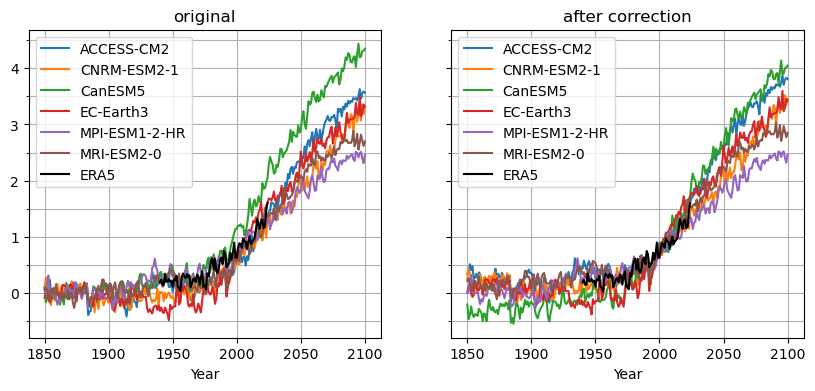

In [103]:
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74

fig,axes=plt.subplots(1,2,figsize=(10,4), sharey=True)

# original 
df_scenario.plot(ax=axes[0])
axes[0].set_title('original')
# corrected
(df_scenario - df_scenario.loc[1985:2014].mean() + gmt_anomaly_correction).plot(ax=axes[1])
axes[1].set_title('after correction')


for ax in axes:
    gmt_obs['ERA5'].plot(ax=ax, c='k')
    #gmt_obs['HadCRUT5'].plot(ax=ax, c='k', ls='--')
    ax.grid()
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.grid(True, which='minor')
    ax.legend()

